# Notebook 02 — Feature Engineering

Builds all 30+ engineered features used across every model in this project.

| Category | Count | Examples |
|---|---|---|
| Log transforms | 3 | `log_loan_amnt`, `log_dti`, `log_revol_bal` |
| Credit score | 2 | `fico_avg`, `fico_int_rate_interaction` |
| Interaction terms | 9 | `grade_interest_interaction`, `dti_income_interaction` |
| Squared terms | 3 | `int_rate_squared`, `delinq_squared`, `annual_income_squared` |
| Ratio features | 5 | `loan_amnt_to_income_ratio`, `payment_to_income_ratio` |
| Regional aggregates | 5 | `zip_region`, `mean_int_rate_by_region`, `relative_int_rate` |

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import run_full_pipeline, NUMERICAL_FEATURES, CATEGORICAL_FEATURES

plt.rcParams['figure.dpi'] = 120

In [2]:
# Run full pipeline: load → clean → engineer features
loan_data = run_full_pipeline('../data/raw/lc_loan.csv')
print(f'Shape after preprocessing: {loan_data.shape}')
print(f'\nNumerical features ({len(NUMERICAL_FEATURES)}):')
for f in sorted(NUMERICAL_FEATURES): print(f'  {f}')

Shape after preprocessing: (933159, 64)

Numerical features (24):
  annual_inc
  composite_loan_feature
  delinq_int_rate_interaction
  delinq_squared
  dti_income_interaction
  fico_avg
  fico_int_rate_interaction
  fico_int_rate_ratio
  fico_loan_interaction
  grade_dti_interaction
  grade_interest_interaction
  installment_fico_interaction
  int_rate_squared
  loan_amnt_to_income_ratio
  loan_to_purpose_amnt_ratio
  log_annual_inc
  log_dti
  log_loan_amnt
  log_revol_bal
  payment_to_income_ratio
  purpose_loan_amnt_interaction
  relative_int_rate
  revol_loan_interaction
  revol_util_income_interaction


## 1. Log transformations — before vs after

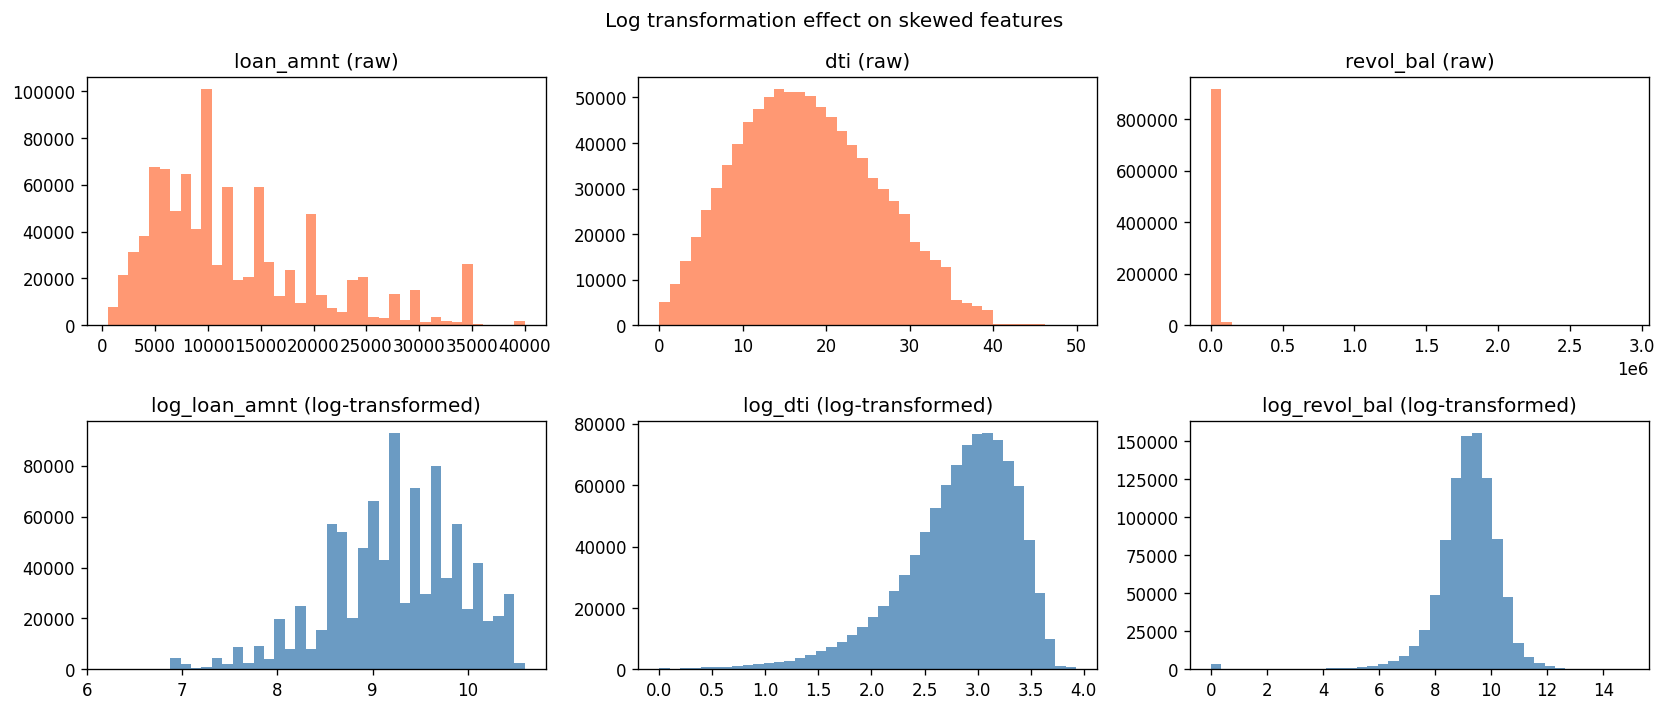

In [3]:
log_pairs = [('loan_amnt', 'log_loan_amnt'), ('dti', 'log_dti'), ('revol_bal', 'log_revol_bal')]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for col_i, (raw, log) in enumerate(log_pairs):
    axes[0, col_i].hist(loan_data[raw].dropna(), bins=40, color='coral', alpha=0.8)
    axes[0, col_i].set_title(f'{raw} (raw)')
    axes[1, col_i].hist(loan_data[log].dropna(), bins=40, color='steelblue', alpha=0.8)
    axes[1, col_i].set_title(f'{log} (log-transformed)')

plt.suptitle('Log transformation effect on skewed features')
plt.tight_layout()
plt.show()

## 2. Interaction term correlations with targets

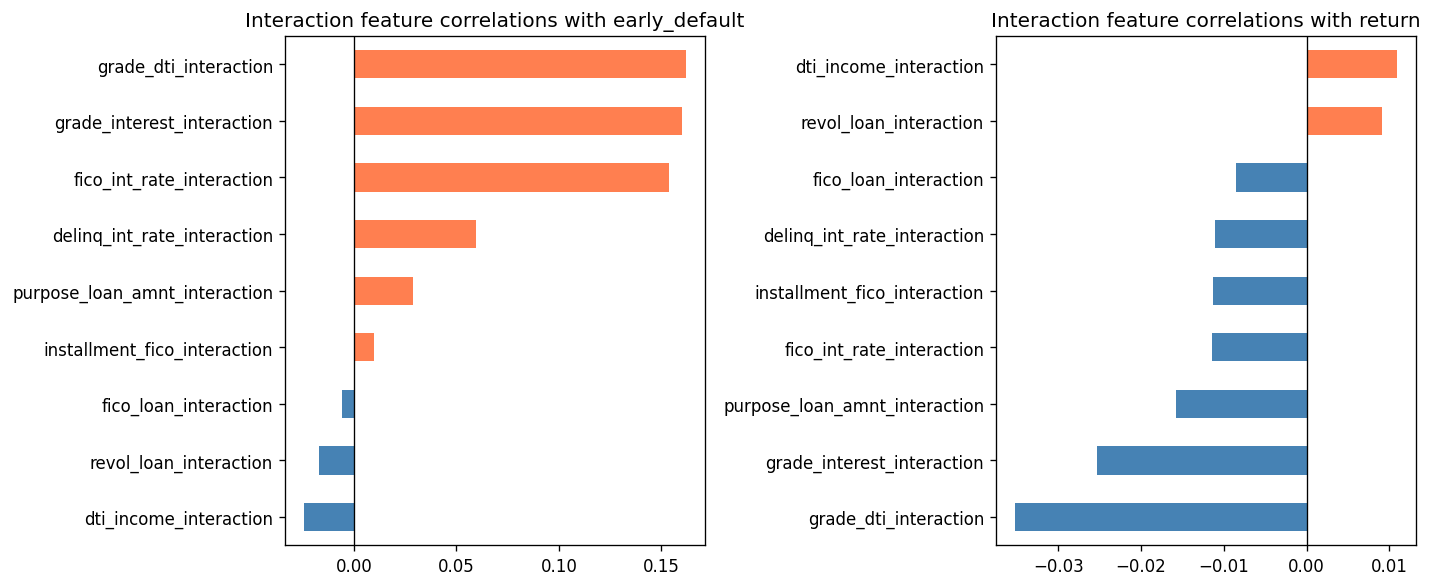

In [4]:
interaction_features = [
    'grade_interest_interaction', 'fico_int_rate_interaction', 'fico_loan_interaction',
    'delinq_int_rate_interaction', 'dti_income_interaction', 'revol_loan_interaction',
    'installment_fico_interaction', 'grade_dti_interaction', 'purpose_loan_amnt_interaction',
]

target_corr = loan_data[interaction_features + ['early_default', 'return']].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

corr_default = target_corr['early_default'][interaction_features].sort_values()
corr_default.plot(kind='barh', ax=axes[0], color=['coral' if x > 0 else 'steelblue' for x in corr_default])
axes[0].set_title('Interaction feature correlations with early_default')
axes[0].axvline(0, color='black', linewidth=0.8)

corr_return = target_corr['return'][interaction_features].sort_values()
corr_return.plot(kind='barh', ax=axes[1], color=['coral' if x > 0 else 'steelblue' for x in corr_return])
axes[1].set_title('Interaction feature correlations with return')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 3. Regional feature distribution

`zip_region` (first 3 digits of ZIP) creates 900+ regional buckets. `mean_int_rate_by_region` captures local lending conditions. `relative_int_rate` shows whether a borrower pays above or below their region's average.

Unique zip regions: 930


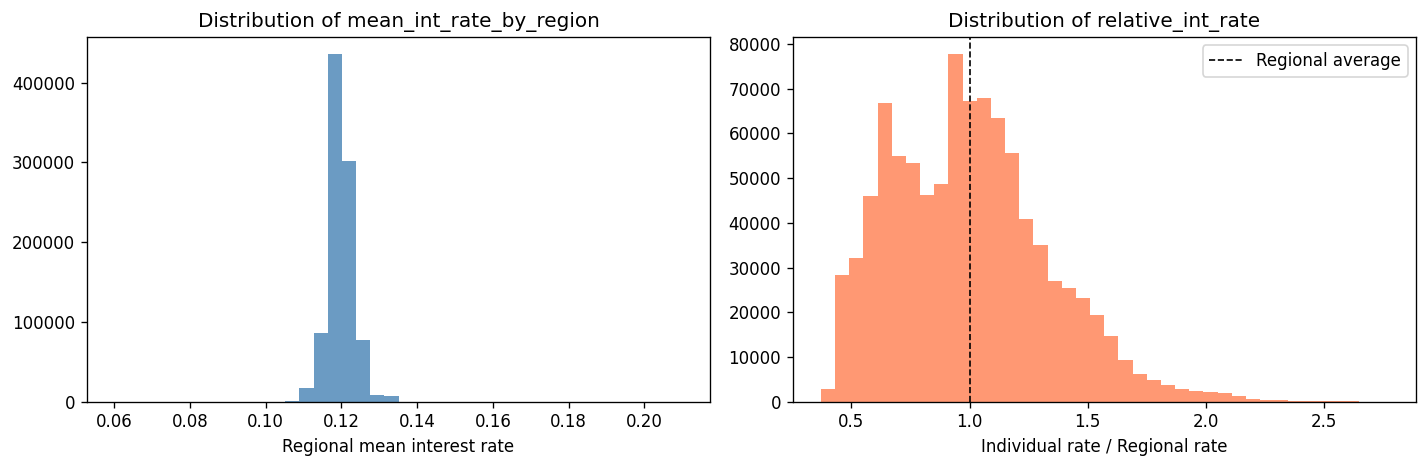

In [5]:
print(f"Unique zip regions: {loan_data['zip_region'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(loan_data['mean_int_rate_by_region'], bins=40, color='steelblue', alpha=0.8)
axes[0].set_title('Distribution of mean_int_rate_by_region')
axes[0].set_xlabel('Regional mean interest rate')

axes[1].hist(loan_data['relative_int_rate'], bins=40, color='coral', alpha=0.8)
axes[1].set_title('Distribution of relative_int_rate')
axes[1].set_xlabel('Individual rate / Regional rate')
axes[1].axvline(1.0, color='black', linewidth=1, linestyle='--', label='Regional average')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Feature correlation matrix (engineered features only)

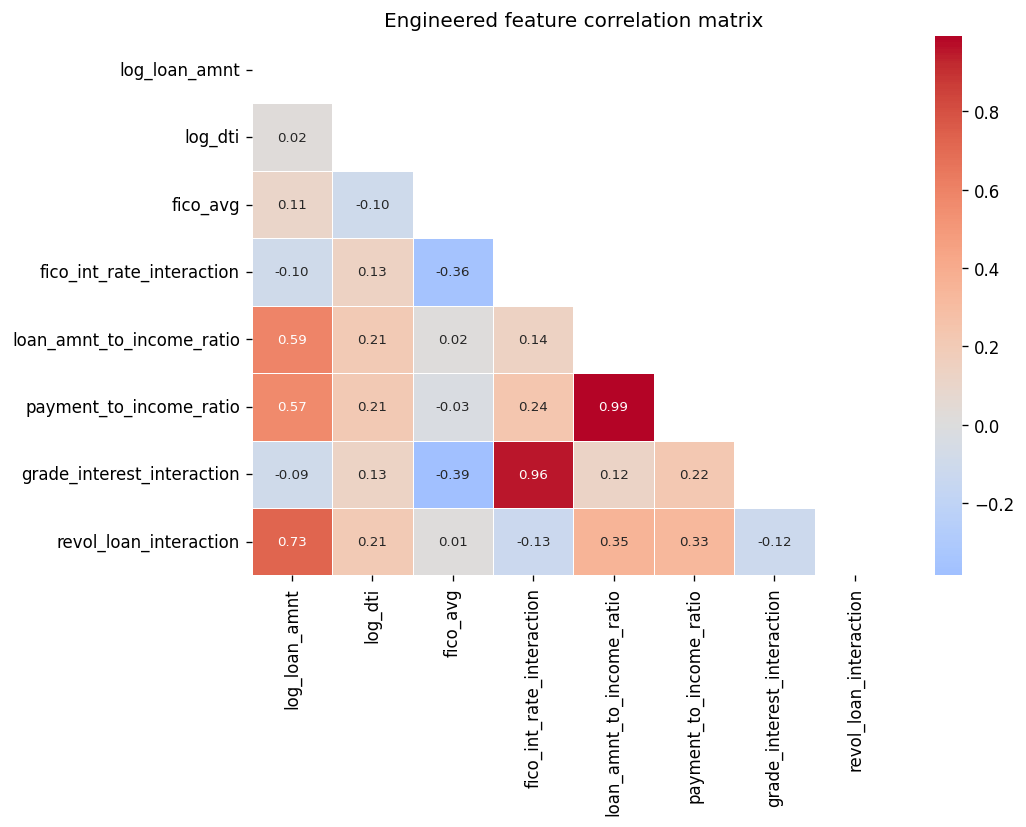

In [6]:
# Check for multicollinearity among engineered features
sample_features = [
    'log_loan_amnt', 'log_dti', 'fico_avg', 'fico_int_rate_interaction',
    'loan_amnt_to_income_ratio', 'payment_to_income_ratio',
    'grade_interest_interaction', 'revol_loan_interaction',
]

fig, ax = plt.subplots(figsize=(9, 7))
corr = loan_data[sample_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.3, annot_kws={'size': 8})
ax.set_title('Engineered feature correlation matrix')
plt.tight_layout()
plt.show()

## 5. Save the preprocessed dataset

In [7]:
# Save to parquet for fast loading in subsequent notebooks
import os
os.makedirs('../data/processed', exist_ok=True)
loan_data.to_parquet('../data/processed/loan_data_features.parquet', index=False)
print(f'Saved to ../data/processed/loan_data_features.parquet')
print(f'Shape: {loan_data.shape}')
print(f'Columns: {list(loan_data.columns)}')

Saved to ../data/processed/loan_data_features.parquet
Shape: (933159, 64)
Columns: ['id', 'loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies', 'tax_liens', 'year', 'early_default', 'return', 'fico_avg', 'zip_region', 'purpose_encoded', 'sub_grade_encoded', 'log_loan_amnt', 'log_dti', 'log_revol_bal', 'log_annual_inc', 'grade_interest_interaction', 'fico_int_rate_interaction', 'fico_loan_interaction', 'delinq_int_rate_interaction', 'dti_income_interaction', 'grade_dti_interaction', 'revol_loan_interaction', 'purpose_loan_amnt_interaction'